<a href="https://colab.research.google.com/github/anushrihub/Array-1/blob/master/Uber_Demand_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Definition**

## **Context**



**Uber Technologies, Inc.** is an American multinational transportation network company based in San Francisco, with operations in approximately 72 countries and 10,500 cities. In the fourth quarter of 2021, Uber had 118 million monthly active users worldwide and generated an average of 19 million trips per day.

Ridesharing is a volatile market, and demand fluctuates with time, place, weather, and local events. The key to succeeding in this business is detecting patterns in these fluctuations and catering to demand at any given time.

As a newly hired Data Scientist in Uber's New York office, you have been asked to extract insights from data that will help the business understand its demand profile and take actions that drive better outcomes.

## **Objective**


To extract actionable insights around demand patterns across various factors that influence Uber pickups in New York City.

## **Key Questions**


1. What are the different variables that influence pickups?
2. Which factor affects pickups the most? What could be plausible reasons for that?
3. What are your recommendations to Uber management to capitalize on fluctuating demand?

## **Data Dictionary**


The data contains information about the weather, location, and pickups.

| Column | Description |
| --- | --- |
| `pickup_dt` | Date and time of the pick-up |
| `borough` | NYC's borough |
| `pickups` | Number of pickups for the period |
| `spd` | Wind speed in miles/hour |
| `vsb` | Visibility in miles to the nearest tenth |
| `temp` | Temperature in Fahrenheit |
| `dewp` | Dew point in Fahrenheit |
| `slp` | Sea level pressure |
| `pcp01` | 1-hour liquid precipitation |
| `pcp06` | 6-hour liquid precipitation |
| `pcp24` | 24-hour liquid precipitation |
| `sd` | Snow depth in inches |
| `hday` | Holiday (Y) or not (N) |

# **Installing and Importing the Necessary Libraries**

In [ ]:
# Installing the necessary libraries
# !pip install numpy pandas matplotlib seaborn

# Importing the necessary libraries
import numpy as np                 # numerical operations
import pandas as pd                # data loading and manipulation
import matplotlib.pyplot as plt    # plotting
import seaborn as sns              # statistical visualizations


# **Topic 1: Data Loading and Overview**

### Generation Prompt

> I have a CSV file called `Uber.csv` with hourly pickup data for NYC boroughs, along with weather information. Can you load it into a pandas DataFrame, show the first 5 rows, the shape of the data, and a quick summary using `info()` and `describe()`?

In [ ]:
# pick the file from the local system
from google.colab import files
uploaded = files.upload()

Saving Uber.csv to Uber.csv


In [ ]:
# Loading the dataset and getting a first look

import pandas as pd

data = pd.read_csv('Uber.csv')  # update the path if needed

# Copying the data so the original stays untouched
df = data.copy()

print("Shape of the data:", df.shape)
display(df.head())
df.info()
df.describe().T

Shape of the data: (29101, 13)


,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pickup_dt  29101 non-null  object 
 1   borough    26058 non-null  object 
 2   pickups    29101 non-null  int64  
 3   spd        29101 non-null  float64
 4   vsb        29101 non-null  float64
 5   temp       29101 non-null  float64
 6   dewp       29101 non-null  float64
 7   slp        29101 non-null  float64
 8   pcp01      29101 non-null  float64
 9   pcp06      29101 non-null  float64
 10  pcp24      29101 non-null  float64
 11  sd         29101 non-null  float64
 12  hday       29101 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 2.9+ MB


,count,mean,std,min,25%,50%,75%,max
pickups,29101.0,490.215903,995.649536,0.0,1.0,54.0,449.000000,7883.00
spd,29101.0,5.984924,3.699007,0.0,3.0,6.0,8.000000,21.00
vsb,29101.0,8.818125,2.442897,0.0,9.1,10.0,10.000000,10.00
temp,29101.0,47.669042,19.814969,2.0,32.0,46.0,64.500000,89.00
dewp,29101.0,30.823065,21.283444,-16.0,14.0,30.0,50.000000,73.00
slp,29101.0,1017.817938,7.768796,991.4,1012.5,1018.2,1022.900000,1043.40
pcp01,29101.0,0.003830,0.018933,0.0,0.0,0.0,0.000000,0.28
pcp06,29101.0,0.026129,0.093125,0.0,0.0,0.0,0.000000,1.24
pcp24,29101.0,0.090464,0.219402,0.0,0.0,0.0,0.050000,2.10
sd,29101.0,2.529169,4.520325,0.0,0.0,0.0,2.958333,19.00


### Explanation

- `pd.read_csv()` reads the file into a **DataFrame**, pandas' table-like structure built on top of NumPy arrays.
- `df.shape` returns `(rows, columns)`, so we immediately know how much data we are working with.
- `df.head()` shows the first 5 rows to get a feel for the columns and their values.
- `df.info()` lists every column, its data type, and how many non-null values it has. This is the fastest way to spot missing data.
- `df.describe()` gives count, mean, standard deviation, min, max, and quartiles for numeric columns. Transposing with `.T` makes it easier to read when there are many columns.

**Key takeaway:** Before doing any analysis, always look at the shape, the data types, and a summary of the values. This tells you what cleaning is needed before you can trust any chart or number.

### Modification Prompt

> Can you also show me a summary of the categorical columns, `borough` and `hday`? I want to know how many unique boroughs there are and how many records fall on holidays.

In [ ]:
# Summary of categorical columns

    df.describe(exclude="number").T

,count,unique,top,freq
pickup_dt,29101,4343,2015-06-30 23:00:00,7
borough,26058,6,Bronx,4343
hday,29101,2,N,27980


In [ ]:
# Counting records in each category

cat_col = ["borough", "hday"]

for col in cat_col:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print()

Value counts for borough:
borough
Bronx            4343
Brooklyn         4343
EWR              4343
Manhattan        4343
Queens           4343
Staten Island    4343
Name: count, dtype: int64

Value counts for hday:
hday
N    27980
Y     1121
Name: count, dtype: int64



### Explanation

- `describe(exclude="number")` switches the summary to text columns, showing the count, number of unique values, the most frequent value, and its frequency.
- `value_counts()` breaks that down further, listing exactly how many records fall into each category.
- We can already see `borough` has six categories and `hday` has two (`Y` and `N`), with far fewer holidays than regular days, which makes sense in a full year of data.

This kind of quick categorical check tells us whether a variable is balanced or skewed, which matters later when comparing pickups across categories.


# **Topic 2: Data Cleaning and a NumPy Check**

### Generation Prompt

> Check if there are any missing values in the data. If `borough` has missing values, replace them with the label `"Unknown"` instead of dropping the rows.

In [ ]:
# Checking for missing values

df.isna().sum()

,0
pickup_dt,0
borough,3043
pickups,0
spd,0
vsb,0
temp,0
dewp,0
slp,0
pcp01,0
pcp06,0


In [ ]:
# Replacing missing boroughs with "Unknown" instead of dropping rows

df["borough"] = df["borough"].fillna("Unknown")

# Confirming there are no missing values left
df.isna().sum()

,0
pickup_dt,0
borough,0
pickups,0
spd,0
vsb,0
temp,0
dewp,0
slp,0
pcp01,0
pcp06,0


### Explanation

- `df.isna().sum()` adds up the missing values in every column. Only `borough` has gaps here.
- `fillna("Unknown")` replaces every missing value in that column with the label `"Unknown"` rather than removing the row. Dropping rows would also throw away the weather data attached to them, which we still need.
- Running `isna().sum()` again confirms the fix worked.

**Key takeaway:** Missing data should be handled deliberately. Dropping rows is not always the safest option, especially when the rest of the row still carries useful information.

### Explanation Prompt

> The `pickups` column is a whole number for every row. Can you show me how NumPy computes basic statistics on it directly, and how that compares with pandas' built-in functions?

In [ ]:
# Comparing NumPy and pandas on the same column

import numpy as np

pickups_array = df["pickups"].to_numpy()

print("Type of pickups_array:", type(pickups_array))
print("NumPy mean:", np.mean(pickups_array))
print("pandas mean:", df["pickups"].mean())
print("NumPy 90th percentile:", np.percentile(pickups_array, 90))
print("NumPy standard deviation:", np.std(pickups_array))

Type of pickups_array: <class 'numpy.ndarray'>
NumPy mean: 490.2159032335659
pandas mean: 490.2159032335659
NumPy 90th percentile: 1689.0
NumPy standard deviation: 995.6324285610172


### Explanation

- `to_numpy()` converts a pandas Series into a plain NumPy array. A pandas Series is, underneath, a NumPy array with a label attached to each value.
- `np.mean()`, `np.std()`, and `np.percentile()` are NumPy functions that operate directly on the array. They return the same mean as pandas' `.mean()` because pandas uses NumPy internally to do the math.
- This matters because it explains why pandas feels fast: every column-wide calculation is really a NumPy operation running under the hood.

Knowing both tools helps when you need a quick statistic (`NumPy`) versus when you need it tied back to a labeled DataFrame for further work (`pandas`).


# **Topic 3: Selecting and Filtering Data**

### Generation Prompt

> First, extract the month, day, weekday name, and hour from `pickup_dt` into their own columns, since we will need them later. Then show me all records for Manhattan where pickups were greater than 5000, using only the `borough`, `pickups`, and `temp` columns.

In [ ]:
# Extracting date parts for later use

df["pickup_dt"] = pd.to_datetime(df["pickup_dt"])

df["start_month"] = df["pickup_dt"].dt.month_name()
df["start_day"] = df["pickup_dt"].dt.day
df["week_day"] = df["pickup_dt"].dt.day_name()
df["start_hour"] = df["pickup_dt"].dt.hour

df.head()

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday,start_month,start_day,week_day,start_hour
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,January,1,Thursday,1
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,January,1,Thursday,1
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,January,1,Thursday,1
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,January,1,Thursday,1
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y,January,1,Thursday,1


In [ ]:
# Conditional indexing: Manhattan rides with more than 5000 pickups

high_demand = df[(df["borough"] == "Manhattan") & (df["pickups"] > 5000)]

# loc selects rows and columns by label
high_demand.loc[:, ["borough", "pickups", "temp"]]

,borough,pickups,temp
3,Manhattan,5258,30.00
1072,Manhattan,5023,23.00
1230,Manhattan,5210,20.00
1388,Manhattan,5246,33.00
1553,Manhattan,5155,23.00
...,...,...,...
28597,Manhattan,7801,61.50
28604,Manhattan,7883,60.00
28611,Manhattan,7711,60.75
28618,Manhattan,7140,60.00


### Explanation

- `pd.to_datetime()` converts the text column into an actual datetime type, unlocking the `.dt` accessor used to pull out month, day, weekday, and hour.
- The condition `(df["borough"] == "Manhattan") & (df["pickups"] > 5000)` is **conditional indexing**: pandas checks each row against both conditions and keeps only the rows where both are true. The `&` combines conditions, and each condition needs its own parentheses.
- `.loc[:, [...]]` selects rows and columns by **label**. The `:` keeps every row from `high_demand`, and the list picks exactly the columns we want to see.

**Key takeaway:** Conditional indexing lets you slice a DataFrame down to only the records relevant to a question, without writing a loop.

### Modification Prompt

> Can you also show me the same thing using `iloc`, by position instead of by label? Just the first 5 matching rows and the first three columns.

In [ ]:
# The same selection using iloc (position-based)

high_demand.iloc[0:5, 0:3]

,pickup_dt,borough,pickups
3,2015-01-01 01:00:00,Manhattan,5258
1072,2015-01-07 19:00:00,Manhattan,5023
1230,2015-01-08 19:00:00,Manhattan,5210
1388,2015-01-09 19:00:00,Manhattan,5246
1553,2015-01-10 20:00:00,Manhattan,5155


### Explanation

- `iloc` selects by **integer position**, not by column name. `0:5` takes the first five rows and `0:3` takes the first three columns, whatever they happen to be named.
- `loc` is safer when you know the column names and want to be explicit. `iloc` is useful when you are working positionally, for example, always wanting "the first few columns" regardless of what they are called.

Both return the same kind of result here because the first three columns in `high_demand` happen to be `borough`, `pickups`, and `temp`.


# **Topic 4: GroupBy and Statistical Functions**

### Generation Prompt

> Can you show me the average number of pickups for each borough, sorted from highest to lowest? Also show me the average pickups on holidays versus non-holidays.

In [ ]:
# Average pickups by borough

df.groupby("borough")["pickups"].mean().sort_values(ascending=False)

,pickups
borough,
Manhattan,2387.253281
Brooklyn,534.431269
Queens,309.354824
Bronx,50.667050
Unknown,2.057180
Staten Island,1.601888
EWR,0.024177


In [ ]:
# Average pickups on holidays vs. non-holidays

df.groupby("hday")["pickups"].mean()

,pickups
hday,
N,492.339957
Y,437.199822


### Explanation

- `groupby("borough")` splits the data into one group per borough. `["pickups"].mean()` then computes the average pickups within each group.
- `sort_values(ascending=False)` orders the result from highest to lowest average, so the busiest borough appears first.
- The same pattern applied to `hday` compares holidays against regular days.

**Key takeaway:** `groupby` is how you answer "average of X, broken down by Y" without writing a loop. It is one of the most common operations in exploratory analysis.

### Modification Prompt

> Can you check if the holiday pattern holds across every borough, not just overall? Group by both borough and holiday status together.

In [ ]:
# Grouping by two columns at once

df.groupby(["borough", "hday"])["pickups"].mean().round(1)

borough        hday
Bronx          N         50.8
               Y         48.1
Brooklyn       N        534.7
               Y        527.0
EWR            N          0.0
               Y          0.0
Manhattan      N       2401.3
               Y       2035.9
Queens         N        308.9
               Y        320.7
Staten Island  N          1.6
               Y          1.5
Unknown        N          2.1
               Y          2.1
Name: pickups, dtype: float64

### Explanation

- Passing a list, `["borough", "hday"]`, to `groupby()` creates one group for every combination of borough and holiday status.
- `round(1)` cleans up the output to one decimal place, which is easier to compare at a glance.
- This confirms whether the overall holiday effect is consistent everywhere or whether one borough behaves differently, which is exactly the kind of detail that turns into a business recommendation.


# **Topic 5: Univariate Visualization**

### Generation Prompt

> Can you create a histogram with a box plot on top for the `pickups` column, so I can see its distribution and spot any outliers? Also add a bar graph showing what percentage of records belong to each borough.

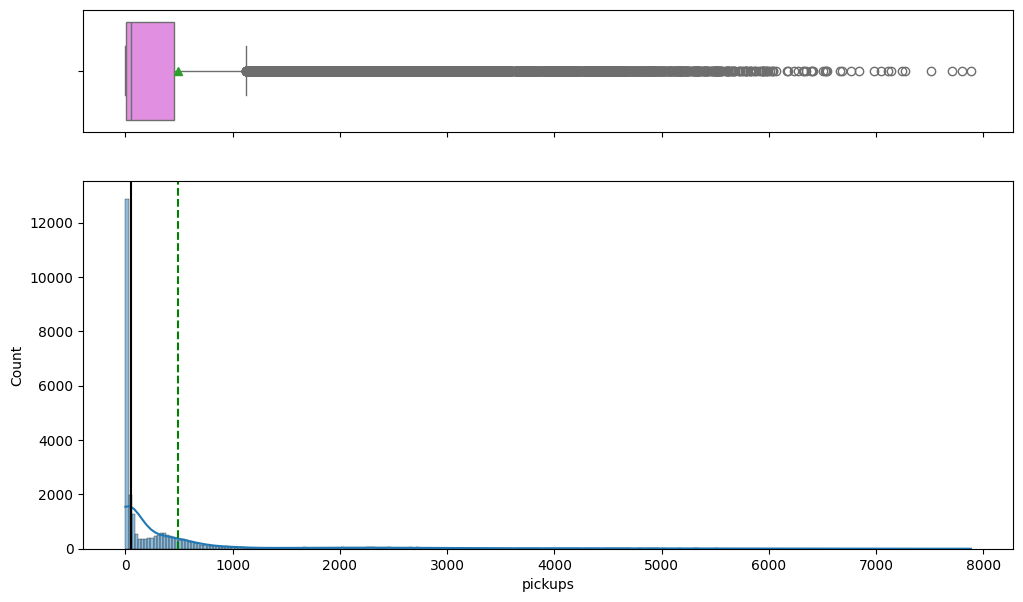

In [ ]:
# Setting up plotting libraries

import matplotlib.pyplot as plt
import seaborn as sns

def histogram_boxplot(data, feature, figsize=(12, 7)):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, sharex=True, gridspec_kw={"height_ratios": (0.25, 0.75)}, figsize=figsize
    )
    sns.boxplot(x=data[feature], ax=ax_box2, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, kde=True, ax=ax_hist2)
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")
    plt.show()

histogram_boxplot(df, "pickups")

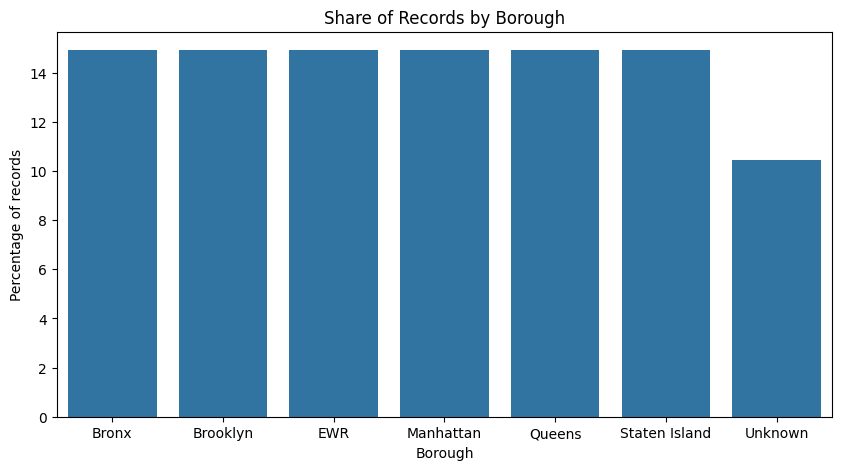

In [ ]:
# Bar graph of the percentage of records per borough

plt.figure(figsize=(10, 5))
borough_pct = df["borough"].value_counts(normalize=True) * 100
sns.barplot(x=borough_pct.index, y=borough_pct.values)
plt.ylabel("Percentage of records")
plt.xlabel("Borough")
plt.title("Share of Records by Borough")
plt.show()

### Explanation

- The histogram shows how often different pickup counts occur, while the box plot above it marks the median, the quartiles, and any outliers as individual points. Placing them together makes it easy to connect a spike in the histogram with its position in the box plot.
- The dashed green line marks the mean and the solid black line marks the median. When they are far apart, the distribution is skewed, which is exactly what we see here: a long right tail of very high-pickup hours.
- The bar graph converts `value_counts()` into percentages, showing whether boroughs are represented evenly in the dataset.

**Key takeaway:** Univariate plots describe one variable at a time. A skewed distribution like `pickups` often calls for a log transform later if you plan to model it, and it also tells you the mean alone would be a misleading summary.


# **Topic 6: Bivariate and Multivariate Visualization**

### Generation Prompt

> Can you show me how pickups change across the hours of the day, split by borough, using a line plot? Also make a scatter plot of temperature versus pickups to see if weather has any relationship with demand.

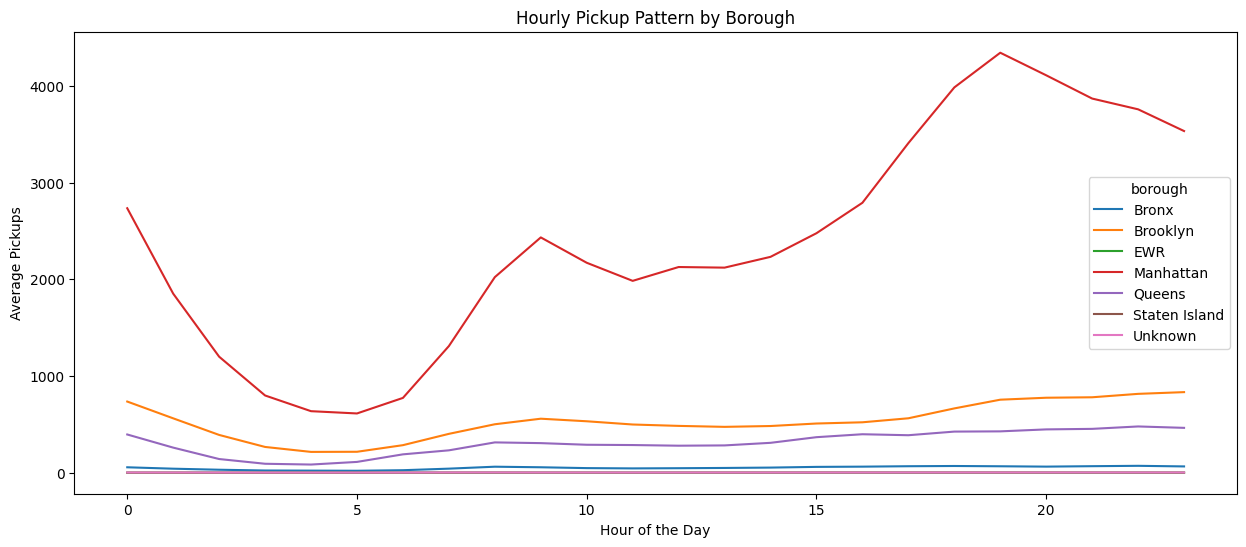

In [ ]:
# Pickups across hours of the day, by borough

plt.figure(figsize=(15, 6))
sns.lineplot(x="start_hour", y="pickups", hue="borough", data=df, errorbar=None)
plt.xlabel("Hour of the Day")
plt.ylabel("Average Pickups")
plt.title("Hourly Pickup Pattern by Borough")
plt.show()

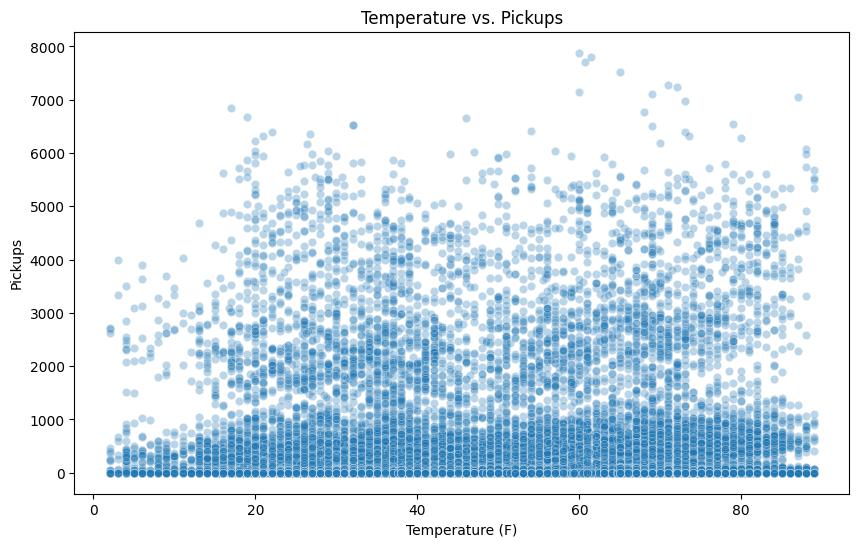

In [ ]:
# Temperature vs. pickups

plt.figure(figsize=(10, 6))
sns.scatterplot(x="temp", y="pickups", data=df, alpha=0.3)
plt.xlabel("Temperature (F)")
plt.ylabel("Pickups")
plt.title("Temperature vs. Pickups")
plt.show()

### Explanation

- `sns.lineplot()` with `hue="borough"` draws one line per borough, all on the same axes, so hourly patterns can be compared directly. `errorbar=None` keeps the chart clean by removing the confidence band.
- The scatter plot places every ride as a point, with `temp` on one axis and `pickups` on the other. `alpha=0.3` makes each point partly transparent, so overlapping points show up as darker patches, revealing where most of the data sits.
- Together these are **bivariate** plots: each one shows the relationship between two variables, rather than describing one variable alone.

**Key takeaway:** Line plots are best for a trend over an ordered variable like time. Scatter plots are best for spotting whether two continuous variables move together.

### Modification Prompt

> For Manhattan specifically, can you create a heat map showing average pickups by weekday and hour together, so I can see exactly when demand peaks?

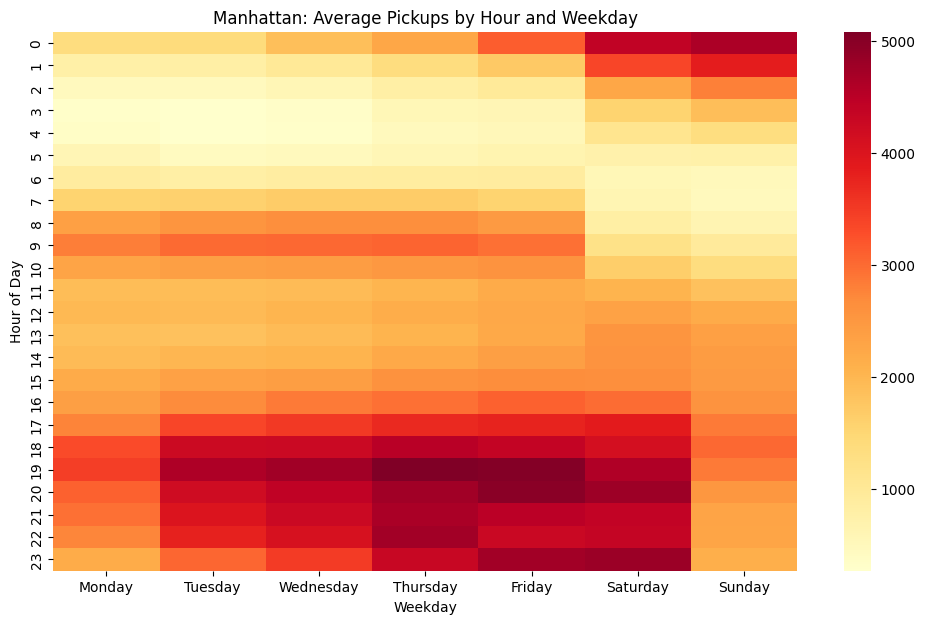

In [ ]:
# Heat map: Manhattan pickups by weekday and hour

manhattan = df[df["borough"] == "Manhattan"]

pivot = manhattan.pivot_table(index="start_hour", columns="week_day", values="pickups", aggfunc="mean")

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
pivot = pivot[weekday_order]

plt.figure(figsize=(12, 7))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Manhattan: Average Pickups by Hour and Weekday")
plt.xlabel("Weekday")
plt.ylabel("Hour of Day")
plt.show()

### Explanation

- `pivot_table()` reshapes the data into a grid: one row per hour, one column per weekday, and each cell holds the average pickups for that combination.
- Reordering the columns with `weekday_order` keeps the days in their natural sequence instead of alphabetical order.
- `sns.heatmap()` colors each cell by its value. Darker or more intense cells mark the busiest hour-and-day combinations, making the peak windows visible at a glance instead of having to scan a table of numbers.

**Key takeaway:** A heat map is the fastest way to spot patterns across two categorical or ordered variables at once. It combines what a line plot and a table would each show separately into a single view.


# Key Insights and Recommendations

Based on the analysis above:

1. **Borough and hour of day** are the strongest drivers of pickup volume, with Manhattan consistently seeing the highest demand and clear peaks during evening commute hours.
2. **Weather variables** like temperature show a weaker, more scattered relationship with pickups compared to time-based factors.
3. **Holidays** tend to reduce average pickups overall, though the effect is not identical across every borough.

**Recommendations for Uber management:**
- Position more drivers in Manhattan during evening peak hours to reduce wait times when demand is highest.
- Use the weekday-hour heat map to plan driver incentives for the specific low-supply windows it reveals.
- Investigate borough-specific holiday behavior further. If one borough does not follow the general holiday drop, local events may be driving demand that a blanket policy would miss.